In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_validate
from scipy.stats import randint, uniform
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score, make_scorer
import joblib
from Utils import shifted_mape, plot_performance_analysis

ModuleNotFoundError: No module named 'Utils'

In [ ]:
X = pd.read_csv('./dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
y_columns = [f'V{i}' for i in range(2,15)] + ['PERD', 'QGEN7'] #V1 ES SIEMPRE 1.0 EN DATASET
Y = pd.read_csv('./dataset/dataset_out.txt', index_col=0).loc[:, y_columns]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]
#NORMALIZACIÓN DE ATRIBUTOS PARA FACILITAR COMPARACIÓN ENTRE MODELOS
normalizer_X = MinMaxScaler(feature_range=(0, 1))
X = pd.DataFrame(normalizer_X.fit_transform(X), columns=X.columns, index=X.index)

In [ ]:
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

In [7]:
random_model = RandomForestRegressor(n_jobs=1, random_state=42)
random_grid = {
    'n_estimators': randint(30, 251),
    'max_depth': randint(10, 51),
    'min_samples_split': randint(2, 21),
    'max_features': uniform(0.1, 0.9)
}
random_search = RandomizedSearchCV(random_model, random_grid, n_iter=30,
                                   cv=TimeSeriesSplit(n_splits=3), scoring='neg_mean_squared_error',
                                   n_jobs=-1, verbose=2, random_state=42, return_train_score=True)

In [8]:
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': <scipy.stats....0020915025950>, 'max_features': <scipy.stats....002091501CC50>, 'min_samples_split': <scipy.stats....0020915027A50>, 'n_estimators': <scipy.stats....002090F7B77D0>}"
,n_iter,30
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [11]:
best_random_model = random_search.best_estimator_
print('MSE: ' + str(random_search.best_score_))
random_results = pd.DataFrame(random_search.cv_results_)
random_results.loc[:, ['param_max_depth', 'param_max_features', 'param_min_samples_split',
                       'param_n_estimators', 'mean_test_score']]

MSE: -0.036751817296791896


,param_max_depth,param_max_features,param_min_samples_split,param_n_estimators,mean_test_score
0,48,0.816889,16,136,-0.039813
1,17,0.638793,8,151,-0.037342
2,28,0.189977,12,117,-0.044882
3,45,0.228580,4,179,-0.040715
4,11,0.749799,7,159,-0.049483
5,30,0.655733,13,118,-0.038619
6,36,0.650668,11,249,-0.037704
7,25,0.309494,16,219,-0.040845
8,12,0.873946,8,50,-0.045785
9,18,0.158546,5,118,-0.043160


In [12]:
random_predictions = best_random_model.predict(x_test)
random_MAE = mean_absolute_error(y_test, random_predictions, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
random_MAPE = mean_absolute_percentage_error(y_test + 1.0, random_predictions + 1.0, multioutput='raw_values')
random_R2 = r2_score(y_test, random_predictions, multioutput='raw_values')
random_data_score = np.vstack([random_MAE, random_MAPE, random_R2])
pd.DataFrame(random_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.003172,0.003178,0.003181,0.003181,0.003181,0.003182,0.003179,0.003180,0.003180,0.003180,0.003180,0.004285,0.004285,0.497659,0.028973
MAPE,0.001607,0.001611,0.001613,0.001613,0.001613,0.001614,0.001612,0.001612,0.001613,0.001613,0.001613,0.002165,0.002165,0.056221,0.027444
R2,0.916151,0.917309,0.917920,0.917981,0.918011,0.918062,0.918057,0.918031,0.918061,0.918105,0.918116,0.796686,0.796703,0.947757,0.544559


In [ ]:
joblib.dump(best_random_model, 'models/MO_RandomForest.pkl')

In [ ]:
evaluate_model = RandomForestRegressor(max_depth=38, max_features=0.82, min_samples_split=2, n_estimators=118, n_jobs=1, random_state=42)
evaluate_scoring = {
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': make_scorer(shifted_mape, greater_is_better=False),
    'r2': 'r2'
}
evaluate_results = cross_validate(evaluate_model, X, Y, scoring=evaluate_scoring, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results['test_mape'].mean()))
print('R2: ' + str(evaluate_results['test_r2'].mean()))

**Gráficas de Evaluación**

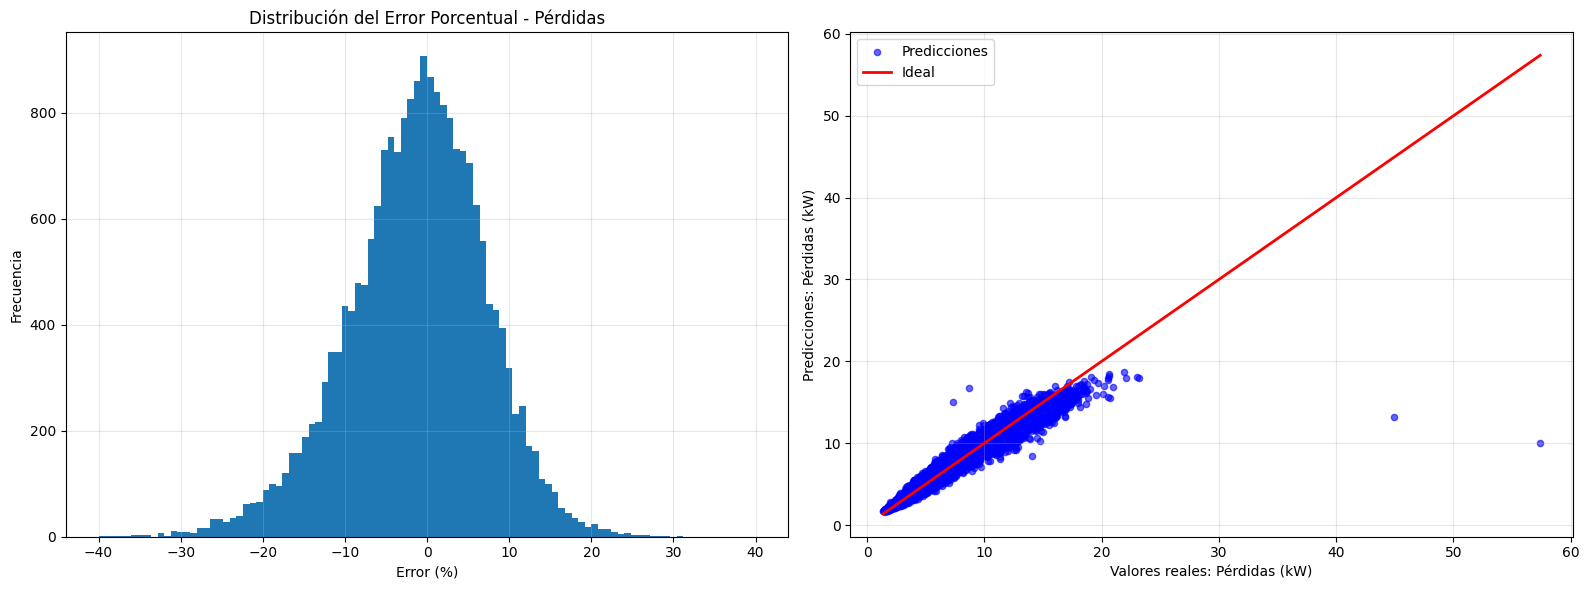

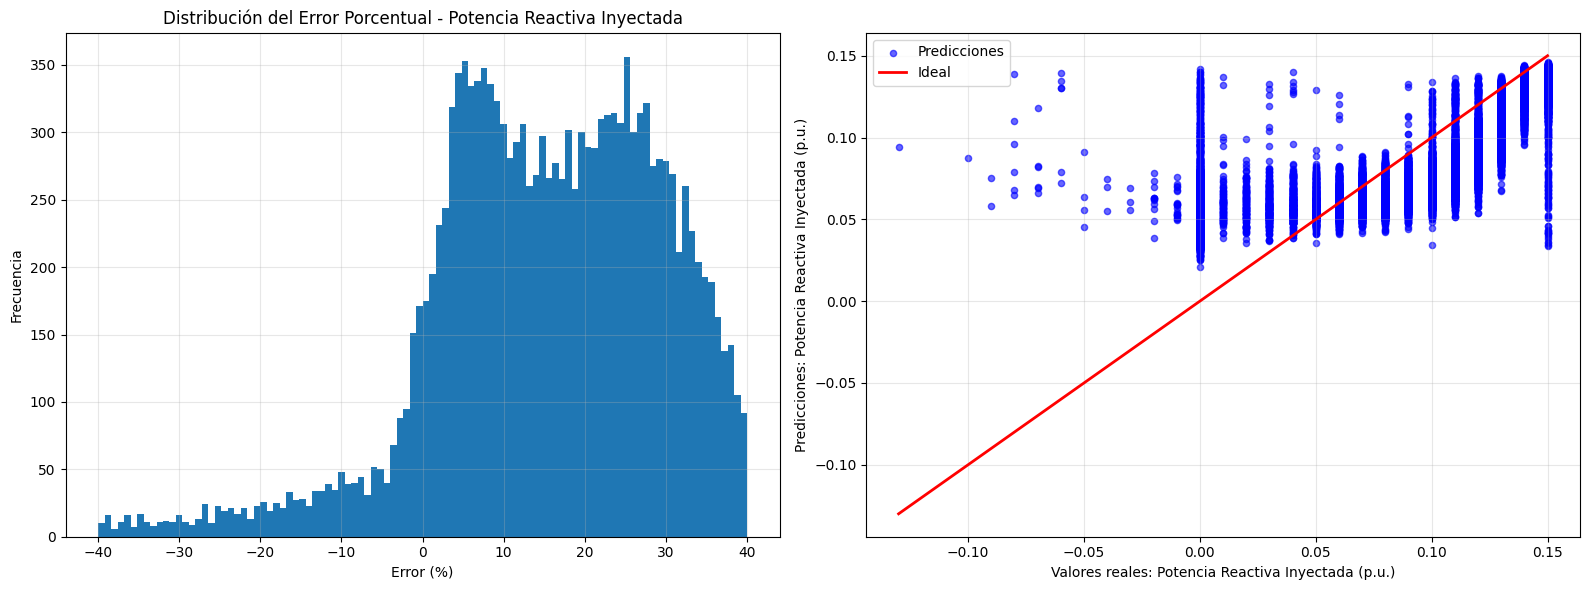

In [36]:
plot_performance_analysis(
    y_test['PERD'],
    random_predictions[:, -2],
    variable_name="Pérdidas",
    unit_label="kW"
)

plot_performance_analysis(
    y_test['QGEN7'],
    random_predictions[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u."
)